# Exercises

We have prepared five exercises in this chapter:

1. Modify the HCM code to work for three groups. This exercise can be divded into four tasks:
    - modify the parameters,
    - modify the calculate_u function,
    - execute the clustering,
    - plot the results.
2. For density clustering, plot the feature space with all element marked with different color, depending on the cluster that it's assigned to. You should do the following tasks:
    - fill the get_color method,
    - fill the plot code.
3. Implement the Dunn index

## Libraries and data imports


In [1]:
import numpy
import random
import numpy as np
import pandas as pd
from math import sqrt
from scipy.spatial.distance import pdist, squareform

import matplotlib.image as img
from PIL import Image

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from IPython.display import Image

import pickle

In [2]:
'''
from google.colab import drive
drive.mount('/content/drive')

with open("#######################################################/Lab-3/data_set.pkl", "rb") as f1:
    data_set = pickle.load(f1)
'''

Mounted at /content/drive


## Exercise 1: HCM

In [3]:
# K-means++
def initialize_centers(data_set, groups):
    centers = [data_set[np.random.randint(len(data_set))]]

    for _ in range(1, groups):
        distances = []
        for x in data_set:
            dist_to_closest = min([np.sum((x - c)**2) for c in centers])
            distances.append(dist_to_closest)

        distances = np.array(distances)
        probabilities = distances / distances.sum()
        cumulative_probabilities = np.cumsum(probabilities)

        r = np.random.rand()
        for i, p in enumerate(cumulative_probabilities):
            if r < p:
                centers.append(data_set[i])
                break

    return np.array(centers)

In [4]:
# parameters
groups = 3
error_margin = 0.0001
m=1                  # m=1 for hard c-means clustering
assignation=np.zeros((len(data_set),groups))
centers = initialize_centers(data_set, groups)
init_centers = centers


def calculate_distance(x,v):
    return sqrt((x[0]-v[0])**2+(x[1]-v[1])**2)

def calculate_new_centers(u):
    new_centers=[]
    for c in range(groups):
        u_x_vector=np.zeros(2)
        u_scalar=0.0
        for i in range(len(data_set)):
            u_scalar = u_scalar+(u[i][c]**m)
            u_x_vector=np.add(u_x_vector,np.multiply(u[i][c]**m,data_set[i]))
        new_centers.append(np.divide(u_x_vector,u_scalar + 1e-10))
    return new_centers

def calculate_differences(new_assignation, assignation):
    return np.sum(np.abs(np.subtract(assignation,new_assignation)))

def cluster_hcm(assignation,centers):
    difference_limit_not_achieved=True
    new_centers = centers
    iter=0
    while difference_limit_not_achieved:
        new_assignation=[]
        for i in range(len(data_set)):
            new_assignation.append(calculate_u_three(data_set[i]))
        new_centers = calculate_new_centers(new_assignation)
        if iter>0:
            if calculate_differences(new_assignation, assignation) < error_margin:
                difference_limit_not_achieved=False
        assignation=new_assignation
        iter=iter+1
    return new_assignation, new_centers

In [5]:
def calculate_u_three(x):
    u_array = np.zeros(groups)
    minimal_distance = []
    for group in range(groups):
        minimal_distance.append(calculate_distance(x, centers[group]))
    min_group_id = np.argmin(minimal_distance)
    u_array[min_group_id] = 1
    return u_array

In [6]:
new_assignation_hcm3, new_centers_hcm3 = cluster_hcm(assignation, centers)

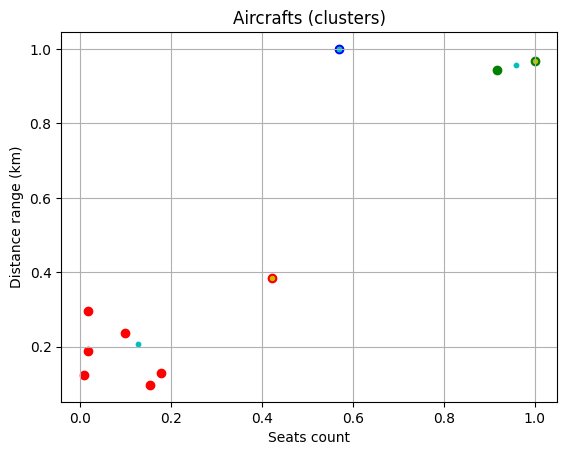

In [7]:
# plot both clusters & centroid initial and ending positions
red = data_set[np.where(np.array(new_assignation_hcm3)[:,0]==1)]
blue = data_set[np.where(np.array(new_assignation_hcm3)[:,1]==1)]
green = data_set[np.where(np.array(new_assignation_hcm3)[:,2]==1)]

fig, ax = plt.subplots()

ax.scatter(blue[:,0],blue[:,1],c='b')
ax.scatter(red[:,0],red[:,1],c='r')
ax.scatter(green[:,0],green[:,1],c='g')
ax.scatter(np.array(init_centers)[:,0],np.array(init_centers)[:,1],c='y',s=8)
ax.scatter(np.array(new_centers_hcm3)[:,0],np.array(new_centers_hcm3)[:,1],c='c',s=10)
ax.set(xlabel='Seats count', ylabel='Distance range (km)',
       title='Aircrafts (clusters)')
ax.grid()
plt.show()

## Exercise 2: Plotting the density clusters

In [8]:
def get_group_objects(color_id):
    return data_set[np.where(np.array(np.argmax(new_assignation_hcm3, axis=1)) == color_id)]

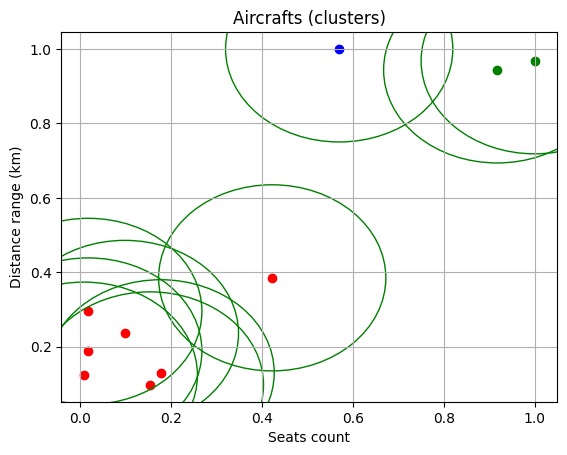

In [9]:
colors = ['red','blue','green','orange','black','yellow']

fig, ax = plt.subplots()

assigned_groups = np.argmax(new_assignation_hcm3, axis=1)
for group in np.unique(assigned_groups):
    small_set = get_group_objects(group)
    ax.scatter(small_set[:,0],small_set[:,1],c=colors.pop(0))
    for circle in small_set:
        circle1 = plt.Circle((circle[0],circle[1]), 0.25, color='green', fill=False)
        ax.add_artist(circle1)

ax.set(xlabel='Seats count', ylabel='Distance range (km)',title='Aircrafts (clusters)')
ax.grid()
plt.show()

## Exercise 3: Dunn index:


In [10]:
def dunn_index(assignation, data_set):
    data_set = np.array(data_set)
    labels = np.argmax(assignation, axis=1)

    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0.0

    dist_matrix = squareform(pdist(data_set))

    max_intra_dist = 0
    for l in unique_labels:
        cluster_points = np.where(labels == l)[0]
        if len(cluster_points) > 1:
            intra_dists = dist_matrix[cluster_points][:, cluster_points]
            max_intra_dist = max(max_intra_dist, np.max(intra_dists))

    if max_intra_dist == 0:
        return 0.0

    min_inter_dist = np.inf
    for i in range(len(unique_labels)):
        for j in range(i + 1, len(unique_labels)):
            idx_i = np.where(labels == unique_labels[i])[0]
            idx_j = np.where(labels == unique_labels[j])[0]

            inter_dists = dist_matrix[idx_i][:, idx_j]
            min_inter_dist = min(min_inter_dist, np.min(inter_dists))

    return min_inter_dist / max_intra_dist

In [11]:
print(f'Dunn Index = {dunn_index(new_assignation_hcm3, data_set)}')

Dunn Index = 0.7187798877017545
